# Coursework submission for CHEM0078 Topic A4 - AI for Chemistry

## Introduction

Here, we are interested in developing a machine learning model that can predict the refractive index of unseen materials from the dataset of DFT calculated refractive indices given. The refractive index (n) is defined as the ratio of the speed of light in a vacuum (c) to the speed of light in a given material ($\nu$) - i.e. $n = \frac{c}{\nu}$.

This notebook contains a full workflow for the development of this model, including data loading, preprocessing, modelling, and evaluation, with each step clearly explained and design decisions justified.

In [79]:
# Importing useful libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Exploratory data analysis

Having generated a dataset containing computed refractive indices for various materials, the first step is to perform exploratory data analysis. The initial motivation for this is to understand the structure of the data and possibly remove any missing or erroneous values.

In [121]:
df = pd.read_pickle("data/student_dataset_2d8b9cff.pkl")
df.info()

print('\nMore information about the objects in column 0:')
print(type(df.iloc[0, 0]))
print(df.iloc[0, 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407 entries, 0 to 1406
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Atoms   1407 non-null   object 
 1   n       1407 non-null   float64
dtypes: float64(1), object(1)
memory usage: 22.1+ KB

More information about the objects in column 0:
<class 'ase.atoms.Atoms'>
Atoms(symbols='P8Pt4', pbc=True, cell=[5.75477911, 5.75477911, 5.75477911], initial_magmoms=...)


We find that we have data for 1407 materials, consisting of a crystal structure given by the `ase.atoms.Atoms` objects and a refractive index which is dimensionless by definition. We start by analysing each variable independently to get a sense of which types of materials are prevalent in our dataset and what the distribution of refractive indices looks like.


### Analysis of material structures

We start by analysing the nature of the materials in our dataset. We want to look at which types of materials are represented more than others, and later inspect whether there is any obvious correlation between classes of materials and refractive index.

In order to make the data easier to analyse, we can introduce an additional column that simply lists the atomic formula of the material, taken directly from the `ase.atoms.Atoms` object. As well as this, we will add a column that contains a list of all the atomic symbols found in the chemical formula, which will allow us to manipulate the structural data more easily to obtain various categories. ASE provides numerous methods to extract further information about the material from the `ase.atoms.Atoms()` object.

In [122]:
# Creating new columns with the chemical formula of the materials

df["Chemical Formula"] = df['Atoms'].apply(lambda atoms: atoms.get_chemical_formula())
df["List of atoms"] = df['Atoms'].apply(lambda atoms: atoms.symbols)

# Creating a new column with the unique elements in each material
df['Unique elements'] = [list(set(s)) for s in df['List of atoms']]

#Creating a dictionary with the number of times each element appears in the dataset
element_list = df["Unique elements"].tolist()

element_counts = {}
for material in element_list:
    for element in material:
        if element in element_counts:
            element_counts[element] += 1
        else:
            element_counts[element] = 1

print(f"There are {len(element_counts)} unique elements in the dataset.")
print(f"The most common element is {max(element_counts, key=element_counts.get)} with {max(element_counts.values())} occurrences.")
print(f"The second most common element is {sorted(element_counts.items(), key=lambda x: x[1], reverse=True)[1][0]} with \
        {sorted(element_counts.items(), key=lambda x: x[1], reverse=True)[1][1]} occurrences.")

print(element_counts['Li'], element_counts['Na'], element_counts['K'], element_counts['Rb'], element_counts['Cs'])


There are 77 unique elements in the dataset.
The most common element is O with 665 occurrences.
The second most common element is Li with         239 occurrences.
239 96 117 78 59


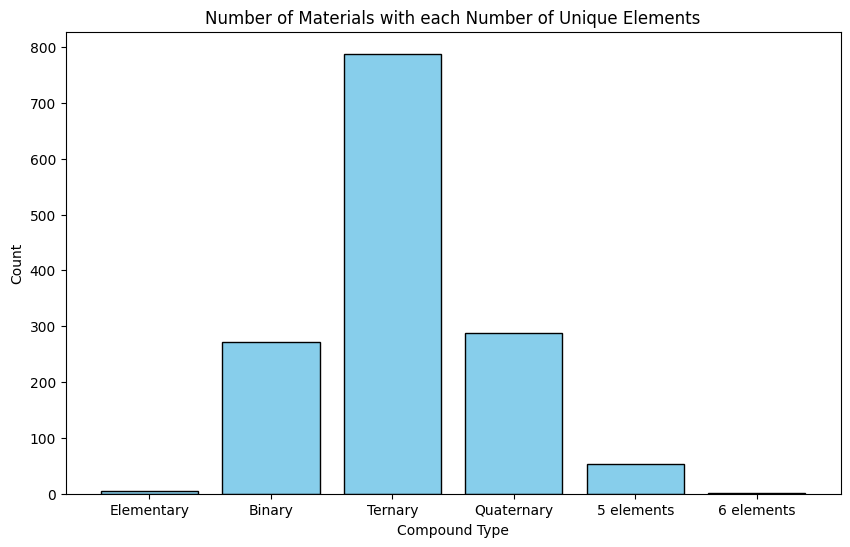

In [123]:

# Classifying how many distinct elements are in present in each material
def get_number_of_elements(unique_atom_list):
    unique_atoms = len(unique_atom_list)
    if unique_atoms == 1:
        return "Elementary"
    elif unique_atoms == 2:
        return "Binary"
    elif unique_atoms == 3:
        return "Ternary"
    elif unique_atoms == 4:
        return "Quaternary"
    else:
        return f"{unique_atoms} elements"


df["Number of Unique Elements"] = df["Unique elements"].apply(get_number_of_elements)

# Plotting the distribution of the number of unique elements in the materials with a bar chart
classes = ["Elementary", "Binary", "Ternary", "Quaternary", "5 elements", "6 elements"]
counts = df["Number of Unique Elements"].value_counts().reindex(classes, fill_value=0)
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color="skyblue", edgecolor="black")
plt.xlabel("Compound Type")
plt.ylabel("Count")
plt.title("Number of Materials with each Number of Unique Elements")
plt.show()



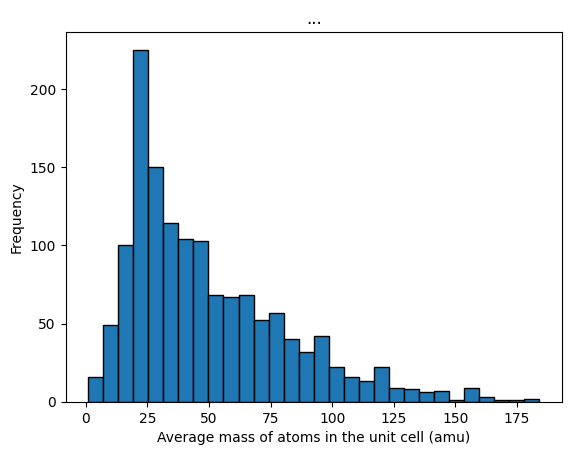

In [124]:
def get_avg_mass(Atoms_obj):
    return Atoms_obj.get_masses().mean() # average mass in the unit cell in atomic mass units

df['Unit Cell Average Mass'] = df['Atoms'].apply(get_avg_mass)

plt.hist(df['Unit Cell Average Mass'].tolist(), bins=30, edgecolor="black")
plt.xlabel("Average mass of atoms in the unit cell (amu)")
plt.ylabel("Frequency")
plt.title("...")
plt.show()

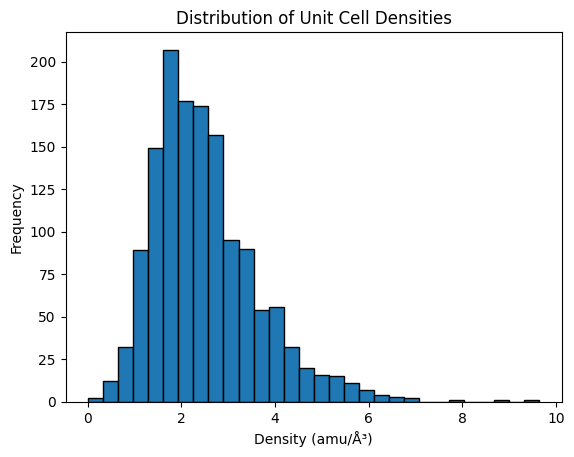

In [125]:
# Seeing the distribution of unit cell densities in the dataset

def get_density(Atoms_obj):
    cell_volume = Atoms_obj.get_volume() # in Anstrom^3
    mass = Atoms_obj.get_masses().sum() # in atomic mass units
    return mass / cell_volume

df['Unit Cell Density'] = df['Atoms'].apply(get_density)

plt.hist(df['Unit Cell Density'].tolist(), bins=30, edgecolor="black")
plt.xlabel("Density (amu/Å³)")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Cell Densities")
plt.show()


In [126]:
df.head(10)

,Atoms,n,Chemical Formula,List of atoms,Unique elements,Number of Unique Elements,Unit Cell Average Mass,Unit Cell Density
0,"(Atom('P', [np.float64(2.244161745057657), np....",4.432306,P8Pt4,"[P, P, P, P, P, P, P, P, Pt, Pt, Pt, Pt]","[P, Pt]",Binary,85.677175,5.394614
1,"(Atom('Ca', [np.float64(4.630853376396311), np...",3.209025,Ca4N4W2,"[Ca, Ca, Ca, Ca, W, W, N, N, N, N]","[N, W, Ca]",Ternary,58.402000,3.195074
2,"(Atom('O', [np.float64(1.9879595859503365), np...",1.942189,O8Rb8Sn4,"[O, O, O, O, O, O, O, O, Rb, Rb, Rb, Rb, Rb, R...","[Sn, O, Rb]",Ternary,64.328720,2.500276
3,"(Atom('Mg', [np.float64(1.0077332293235883), n...",2.387119,Mg4N6Nb2,"[Mg, Mg, Mg, Mg, Nb, Nb, N, N, N, N, N, N]","[N, Mg, Nb]",Ternary,30.589562,2.259319
4,"(Atom('Cs', [np.float64(4.929090473052684), np...",1.547183,HCsO3S,"[Cs, H, S, O, O, O]","[H, O, S, Cs]",Quaternary,35.661742,2.044421
5,"(Atom('Nd', [np.float64(-0.4655589381710817), ...",3.122468,Nd4Pb2S8,"[Nd, Nd, Nd, Nd, Pb, Pb, S, S, S, S, S, S, S, S]","[Pb, Nd, S]",Ternary,89.132000,3.816503
6,"(Atom('P', [np.float64(2.53638721758737), np.f...",2.522956,K8P8,"[P, P, P, P, P, P, P, P, K, K, K, K, K, K, K, K]","[P, K]",Binary,35.036031,1.214016
7,"(Atom('Tm', [np.float64(0.0), np.float64(-9.99...",1.761471,C3H3O6Tm,"[Tm, H, H, H, C, C, C, O, O, O, O, O, O]","[Tm, O, C, H]",Quaternary,23.383478,2.486856
8,"(Atom('Li', [np.float64(1.4107176267877608), n...",3.165078,Co4Li2O8,"[Li, Li, Co, Co, Co, Co, O, O, O, O, O, O, O, O]","[O, Li, Co]",Ternary,26.971770,2.815433
9,"(Atom('O', [np.float64(2.5607431703437267), np...",2.229486,K2O2Tl2,"[O, O, K, K, Tl, Tl]","[O, K, Tl]",Ternary,86.492433,3.488741


### Analysis of refractive index data

We now move on to univariate analysis on the data given for the refractive index of each material. This data is already quantitative and continuous, making analysis more straightforward.

In [127]:
# Summary statistics for the refractive index

df['n'].describe()

count    1407.000000
mean        3.983140
std        14.232948
min         1.000000
25%         1.678075
50%         2.070657
75%         2.638278
max       149.674561
Name: n, dtype: float64

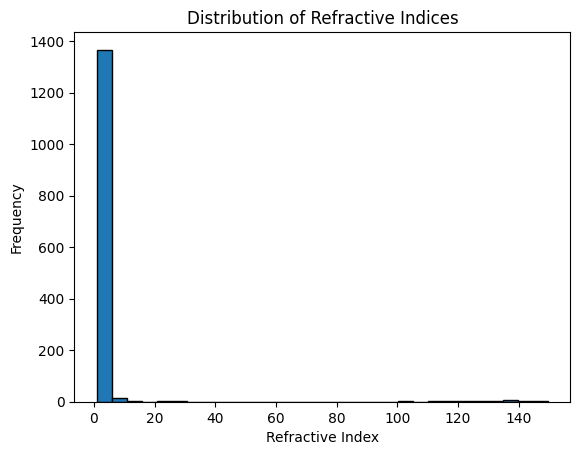

In [128]:
# Plotting the distribution of refractive indices with a histogram

plt.hist(df['n'], bins=30, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices")
plt.show()

In [129]:
outliers = df[df['n'] > 100]

print(f"There are {len(outliers)} materials with a refractive index greater than 100 in the dataset:")
print(outliers['Chemical Formula'])

There are 18 materials with a refractive index greater than 100 in the dataset:
31         LiMn5Na3O9
44       Fe4Li4O16Si4
79       Ca10Cl2O24P6
124     H16Li4N4O16S4
203           S4TaTl3
297            Ca8Si4
345           HGaGeSr
523            BrO3Rb
571        H16B4F16N4
584          CaMg2Sb2
597           N3O6Rb3
880         H8F4O4Rb4
973       Cr2Li2O8Rb2
995      Ge4O14Sr4Zn2
1117            O8Zr4
1183       CoCr3Li2O8
1201        B16Cd8O32
1241          O18P6Y2
Name: Chemical Formula, dtype: object


We immediately find that there is a large standard deviation in the dataset, caused by the presence of apparent outliers. A quick search of the literature shows that refractive indices (measured experimentally) over 5 are exceedingly rare in inorganic materials (cite book), meaning we can be almost entirely confident that datapoints over 100 are innaccurate (perhaps arising from unconverged DFT calculations) and should be discarded.

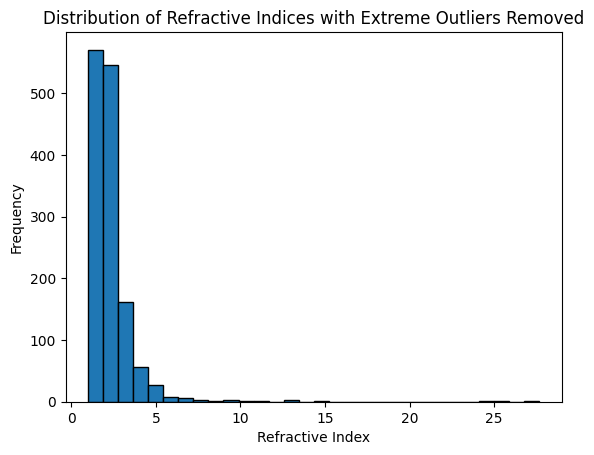

In [130]:
df = df[df['n'] <= 100]

plt.hist(df['n'], bins=30, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices with Extreme Outliers Removed")
plt.show()

Having removed the datapoints with refractive indices over 100, we now see that there is a small number of materials with $n \approx 25$. These values are still quite far outside the range of values that we expect from experimental results ($1 \le n \le 5$) but it is not immediately obvious whether they should be removed.

In [131]:
outliers = df[df['n'] > 20]

print(f"There are {len(outliers)} materials with a refractive index greater than 20 in the dataset:")

top10ndf = df.nlargest(10, "n")
print("The 10 materials with the highest refractive index are:")
print(top10ndf[["Chemical Formula", "n"]])


There are 3 materials with a refractive index greater than 20 in the dataset:
The 10 materials with the highest refractive index are:
     Chemical Formula          n
529           LiMn4O8  27.654889
424         Cu2Si4Zr2  25.192293
1014            NaO2V  24.141936
126           Ca2HgSn  15.012490
749             Br2Fe  12.891263
223          N8Sn4Zn4  12.604127
1273           Cl2OOs  11.357104
1095           Li5Sn2  10.537710
164       Ba12N48Re24   9.538562
1263             HgIn   9.470181


We see that there is a large very gap of almost 10 between the cluster of 3 datapoints around 25 and the rest of the data, which have a relatively smooth distribution of refractive indices between approximately $1 \le n \le 15$. Considering this alongside the fact that refractive indices over 25 are shown to be highly unlikely from experiment, we choose to also remove these 3 data points.

While it is expected that refractive indices in the range of $5 \le n \le 15$ are heavily overestimated, the fact that there is a smooth distribution of datapoints over this range suggests that this error might arise from systematic innacuracy in the DFT calculations, rather than from lack of convergence or other more extreme errors. We keep these values in the dataset since they may still provide some qualitative information and aren't expected to intefere too much with model convergence. Despite that, we will keep this in mind moving forward and may be required to remove these datapoints at a later time.

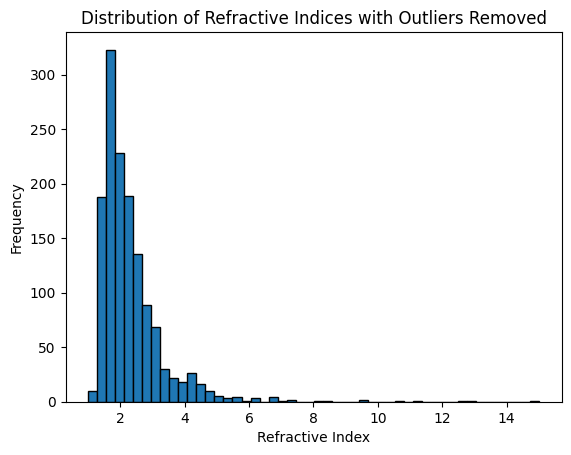

count    1386.000000
mean        2.333858
std         1.123019
min         1.000000
25%         1.675240
50%         2.056079
75%         2.605872
max        15.012490
Name: n, dtype: float64

In [132]:
df = df[df['n'] <= 20]

plt.hist(df['n'], bins=50, edgecolor="black")
plt.xlabel("Refractive Index")
plt.ylabel("Frequency")
plt.title("Distribution of Refractive Indices with Outliers Removed")
plt.show()


df['n'].describe()

We find that now the summary statistics for the refractive indices look reasonable. The standard deviation is 1.12, which is similar to the interquartile range of 0.93


### Multivariate data analysis

We now move on to analyse what relationships and correlations might exist between our structure and refractive index in our material. We can examine these relationships using the parameters that we described previously to categorise the structure - i.e. the unit cell density and the number of unique elements in each material.

R^2 value for the linear regression: 0.2230


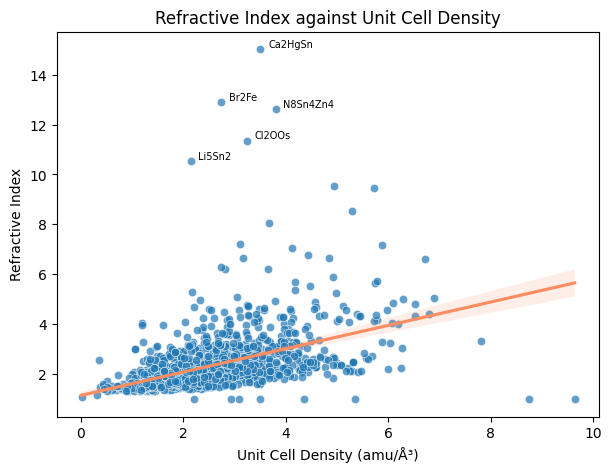

In [134]:
# Examining the realtionship between the refractive index and the unit cell density.

# Computing R^2 for a linear regression between the refractive index and the unit cell density
x = df["Unit Cell Density"].values
y = df["n"].values

coeffs = np.polyfit(x, y, deg=1)
y_pred = np.polyval(coeffs, x)

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

print(f"R^2 value for the linear regression: {r2:.4f}")


# Plotting the relationship between the refractive index and the unit cell density with a scatterplot and a regression line
plt.figure(figsize=(7,5))
# Scatterplot
sns.scatterplot(
    data=df,
    x="Unit Cell Density",
    y="n",
    alpha=0.7
)
# Regression line
sns.regplot(
    data=df,
    x="Unit Cell Density",
    y="n",
    scatter=False,
    color=sns.color_palette("Set2")[1]
)

outliers = df[df['n'] > 10]
for _, row in outliers.iterrows():
    plt.text(
        row["Unit Cell Density"] + 0.15,
        row["n"],
        row["Chemical Formula"],     # <-- replace with your column name
        fontsize=7,
        ha="left",
        va="bottom"
    )

plt.xlabel("Unit Cell Density (amu/Å³)")
plt.ylabel("Refractive Index")
plt.title("Refractive Index against Unit Cell Density")
plt.show()

We find a relatively weak but convincing positive correlation between the unit cell density and the refractive index. This makes sense physically: from a simplistic perspective, a high refractive index implies that light finds struggles to travel through a material, which would be expected for a material with a higher density. This highlights the fact that a correct description of the unit cell in our machine learning model will be essential for obtaining accurate results.

This plot also makes us turn attention back to the data points with $n \lt 10$. We see that these points don't reflect this correlation at all, possessing very high refractive indices but only average densities. This provides further evidence for removing these materials from the dataset. The only thing that obviously links some of these chemical structures together is the presence of tin in three of the materials. We can quickly check below whether the data shows that tin containing materials exhibit unusually high refractive indices.

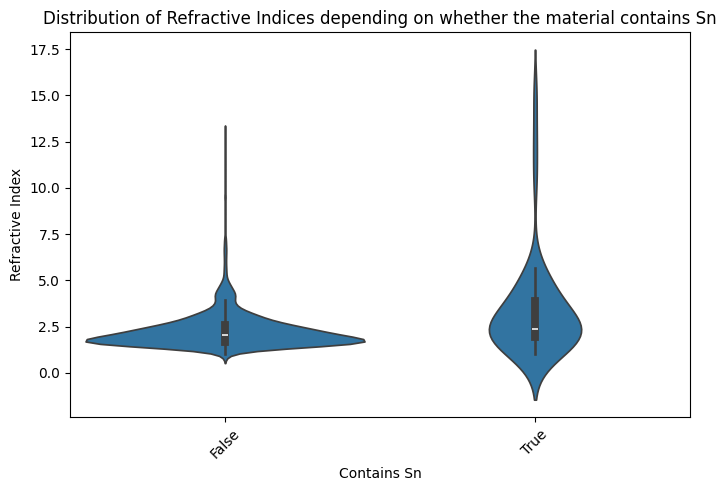

In [135]:
df["Contains Sn"] = df["Unique elements"].apply(lambda elems: "Sn" in elems)

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, 
               x="Contains Sn", y="n", width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices depending on whether the material contains Sn")
plt.show()

df = df.drop(columns=["Contains Sn"])


There doesn't appear to be any significant evidence that the presence of Tin in the outlier materials could explain their unusually high refractive indices. As such, we believe it is justified to remove the 5 materials that have refractive indices over 10 from the dataset. We thus move on to quickly examine any simple relationships that might exist between the composition of the materials and their refractive indices.

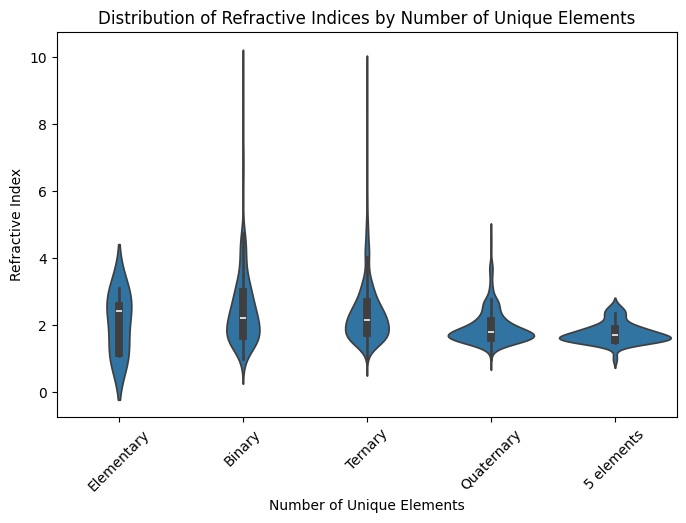

In [136]:
# Removing outliers as mentioned above
df = df[df['n'] <= 10]

import seaborn as sns

classes = ["Elementary", "Binary", "Ternary", "Quaternary", "5 elements"]

plt.figure(figsize=(8, 5))
sns.violinplot(data=df[df["Number of Unique Elements"] != "6 elements"],  # Exclude the "6 elements" class as it only has 1 material
               x="Number of Unique Elements", y="n", order=classes, width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices by Number of Unique Elements")
plt.show()


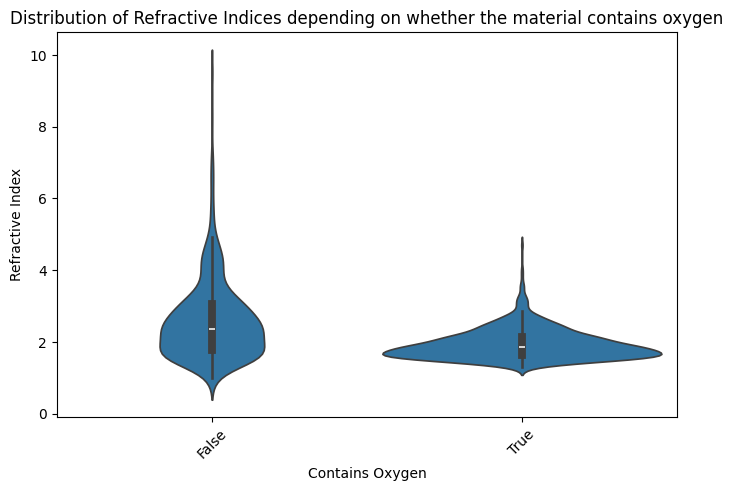

In [137]:
# Since Oxygen is found so commonly in the dataset, we may want to characterise materials based on whether they contain oxygen or not.

df["Contains Oxygen"] = df['Atoms'].apply(lambda atoms: "O" in atoms.symbols)

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, 
               x="Contains Oxygen", y="n", width=0.9)
plt.xticks(rotation=45)
plt.ylabel("Refractive Index")
plt.title("Distribution of Refractive Indices depending on whether the material contains oxygen")
plt.show()

df = df.drop(columns=["Contains Oxygen"])

In [139]:
num_elementary = (df["Number of Unique Elements"] == "Elementary").sum()
num_elementary


np.int64(5)

We see that the number of different elements in the material doesn't appear to have a strong impact on the material's refractive index. There may be a subtle trend showing that the refractive index decreases as the number of different elements in the unit cell increases, noting that...